# Análise dos piores casos — onde cada método erra, e por quê

**Grupo 02 — Segmentação do parênquima pulmonar.** Etapa de **Interpretação** do KDD.

Este notebook responde à **orientação 5 do feedback da Sprint 3**:

> "pode ser que a rede neural ganhe pouco na média e ganhe muito nos casos difíceis.
> Se for isso, esse é o argumento que justifica o trabalho de vocês"

Os números já apontavam nessa direção. O que faltava era **abrir as imagens e explicar o
porquê** — é isso que está aqui.

Para cada exame, plotamos 3 fatias (início, meio e fim do pulmão) com **5 painéis**: TC
original, máscara de referência, e as três predições (baseline, region growing, U-Net 2D)
com as discordâncias em cor:

| Cor | Significado |
|---|---|
| 🟢 verde | acerto — o método e a referência concordam |
| 🔴 vermelho | **falso positivo** — marcou e não é pulmão |
| 🔵 azul | **falso negativo** — é pulmão e não marcou |
| 🟡 amarelo | a referência (painel 2) |

> **Observação importante sobre o que está escrito aqui.** Os comentários descrevem
> **apenas o que é visível na imagem** (área mais densa, contorno, artefato, espessura de
> fatia). Não há afirmação de diagnóstico: dizer que uma região "aparece mais densa" é
> descrição; dizer *por que* ela está densa seria diagnóstico, e isso exige um radiologista.

## 1. Preparação

Rodar sempre **a partir da raiz do repositório**, com caminho relativo (`data/luna16`):
caminho absoluto quebra a leitura do SimpleITK nessa pasta (ver nota em
`scripts/run_sprint4_evaluation.py`).

A lógica pesada (pré-processamento, os 3 métodos, montagem das figuras) está em
`scripts/gerar_piores_casos.py` e é **importada**, não copiada — o projeto mantém a regra
de não duplicar lógica entre notebooks (checklist de reprodutibilidade do Sprint 5).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, 'src')
sys.path.insert(0, 'scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from luna16.unet import load_trained_model, DEVICE
from gerar_piores_casos import (
    CASOS, DATA_DIR, OUT_DIR, preparar, escolher_fatias, metricas, montar_figura,
)

SEED = 42
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'{len(CASOS)} exames a analisar | dispositivo da U-Net: {DEVICE}')
print(f'figuras em: {OUT_DIR}/')

6 exames a analisar | dispositivo da U-Net: cpu
figuras em: docs\piores_casos/


### 1.1. Checagem de vazamento treino/teste

Antes de qualquer conclusão sobre a U-Net: os exames analisados precisam estar **fora** do
treino dela, senão o ganho observado não significaria nada. O checkpoint guarda os
`train_uids`, então dá para verificar diretamente em vez de confiar no split.

In [2]:
import torch

ck = torch.load(DATA_DIR / 'unet_baseline.pt', map_location='cpu', weights_only=False)
treino = set(ck['train_uids'])
split = pd.read_csv(DATA_DIR / 'split_full.csv')
teste = set(split.loc[split['conjunto'] == 'test', 'uid'])

print(f'pacientes no treino da U-Net: {len(treino)}')
print(f'vazamento treino x teste:     {len(treino & teste)}  (tem que ser 0)')
print()
for uid, rotulo, _ in CASOS:
    print(f'  {rotulo:22s} ...{uid[-12:]}  no teste: {uid in teste}  |  no treino: {uid in treino}')

assert len(treino & teste) == 0, 'vazamento entre treino e teste'
assert all(uid in teste and uid not in treino for uid, _, _ in CASOS)
print('\nOK: todos os exames analisados sao de teste e nenhum foi visto no treino.')

pacientes no treino da U-Net: 124
vazamento treino x teste:     0  (tem que ser 0)

  pior-baseline          ...658609808059  no teste: True  |  no treino: False
  baixa-resolucao        ...021509831276  no teste: True  |  no treino: False
  intermediario          ...954024478441  no teste: True  |  no treino: False
  falha-region-growing   ...079549658100  no teste: True  |  no treino: False
  unet-perde             ...696274044574  no teste: True  |  no treino: False
  controle-bom           ...741695800950  no teste: True  |  no treino: False

OK: todos os exames analisados sao de teste e nenhum foi visto no treino.


## 2. Rodando os três métodos

Mesmo pipeline do Sprint 4 para os três métodos (`clean_hu` → `denoise` →
`resample_isotropic` 1 mm), trocando só a função de segmentação — é o que torna a
comparação justa. A U-Net usa os pesos treinados em `data/luna16/unet_baseline.pt`.

In [3]:
modelo = load_trained_model(str(DATA_DIR / 'unet_baseline.pt'))
n_par = sum(p.numel() for p in modelo.parameters())
print(f'U-Net carregada: {n_par:,} parametros (base_ch={ck.get("base_ch", 16)})')

linhas, figuras = [], {}
for i, (uid, rotulo, motivo) in enumerate(CASOS, 1):
    print(f'[{i}/{len(CASOS)}] {rotulo} ...{uid[-12:]}', flush=True)
    vol, ref, tra, preds, tempos, spacing, shape0 = preparar(uid, modelo)
    fatias = escolher_fatias(ref)
    mets = {c: metricas(p, ref, tra) for c, p in preds.items()}

    png = OUT_DIR / f'{i:02d}_{rotulo}_{uid[-12:]}.png'
    montar_figura(vol, ref, preds, fatias, uid, rotulo, mets, png)
    figuras[rotulo] = png

    for metodo, m in mets.items():
        linhas.append({'ordem': i, 'rotulo': rotulo, 'uid': uid, 'uid_curto': uid[-12:],
                       'metodo': metodo, 'arquivo_png': png.name,
                       'fatias': '|'.join(map(str, fatias)),
                       'spacing_z_mm': round(spacing[2], 4), 'spacing_xy_mm': round(spacing[0], 4),
                       'volume_ref_ml': round(int(ref.sum()) * 0.001, 1),
                       'tempo_seg': round(tempos[metodo], 1), **m})

df = pd.DataFrame(linhas)
df.to_csv(OUT_DIR / 'metricas_piores_casos.csv', index=False)
print('\nconcluido')

U-Net carregada: 1,927,841 parametros (base_ch=32)
[1/6] pior-baseline ...658609808059


      baseline: 0.8s


      region_growing: 1.6s


      unet: 5.3s


[2/6] baixa-resolucao ...021509831276


...

[6/6] controle-bom ...741695800950


      baseline: 1.8s


      region_growing: 4.4s


      unet: 11.1s



concluido


In [4]:
# Dice dos 3 metodos lado a lado
tabela = df.pivot_table(index=['ordem', 'rotulo'], columns='metodo', values='dice').reset_index()
tabela = tabela[['ordem', 'rotulo', 'baseline', 'region_growing', 'unet']].sort_values('ordem')
tabela['melhor'] = tabela[['baseline', 'region_growing', 'unet']].idxmax(axis=1)
tabela.round(4)

metodo,ordem,rotulo,baseline,region_growing,unet,melhor
0,1,pior-baseline,0.8468,0.7790,0.9671,unet
1,2,baixa-resolucao,0.8600,0.5941,0.9628,unet
2,3,intermediario,0.9119,0.9212,0.9710,unet
3,4,falha-region-growing,0.9795,0.2263,0.9884,unet
4,5,unet-perde,0.9732,0.9684,0.9281,baseline
5,6,controle-bom,0.9816,0.9759,0.9900,unet


## 3. Caso a caso

### 3.1. Pior caso do baseline — `…658609808059`

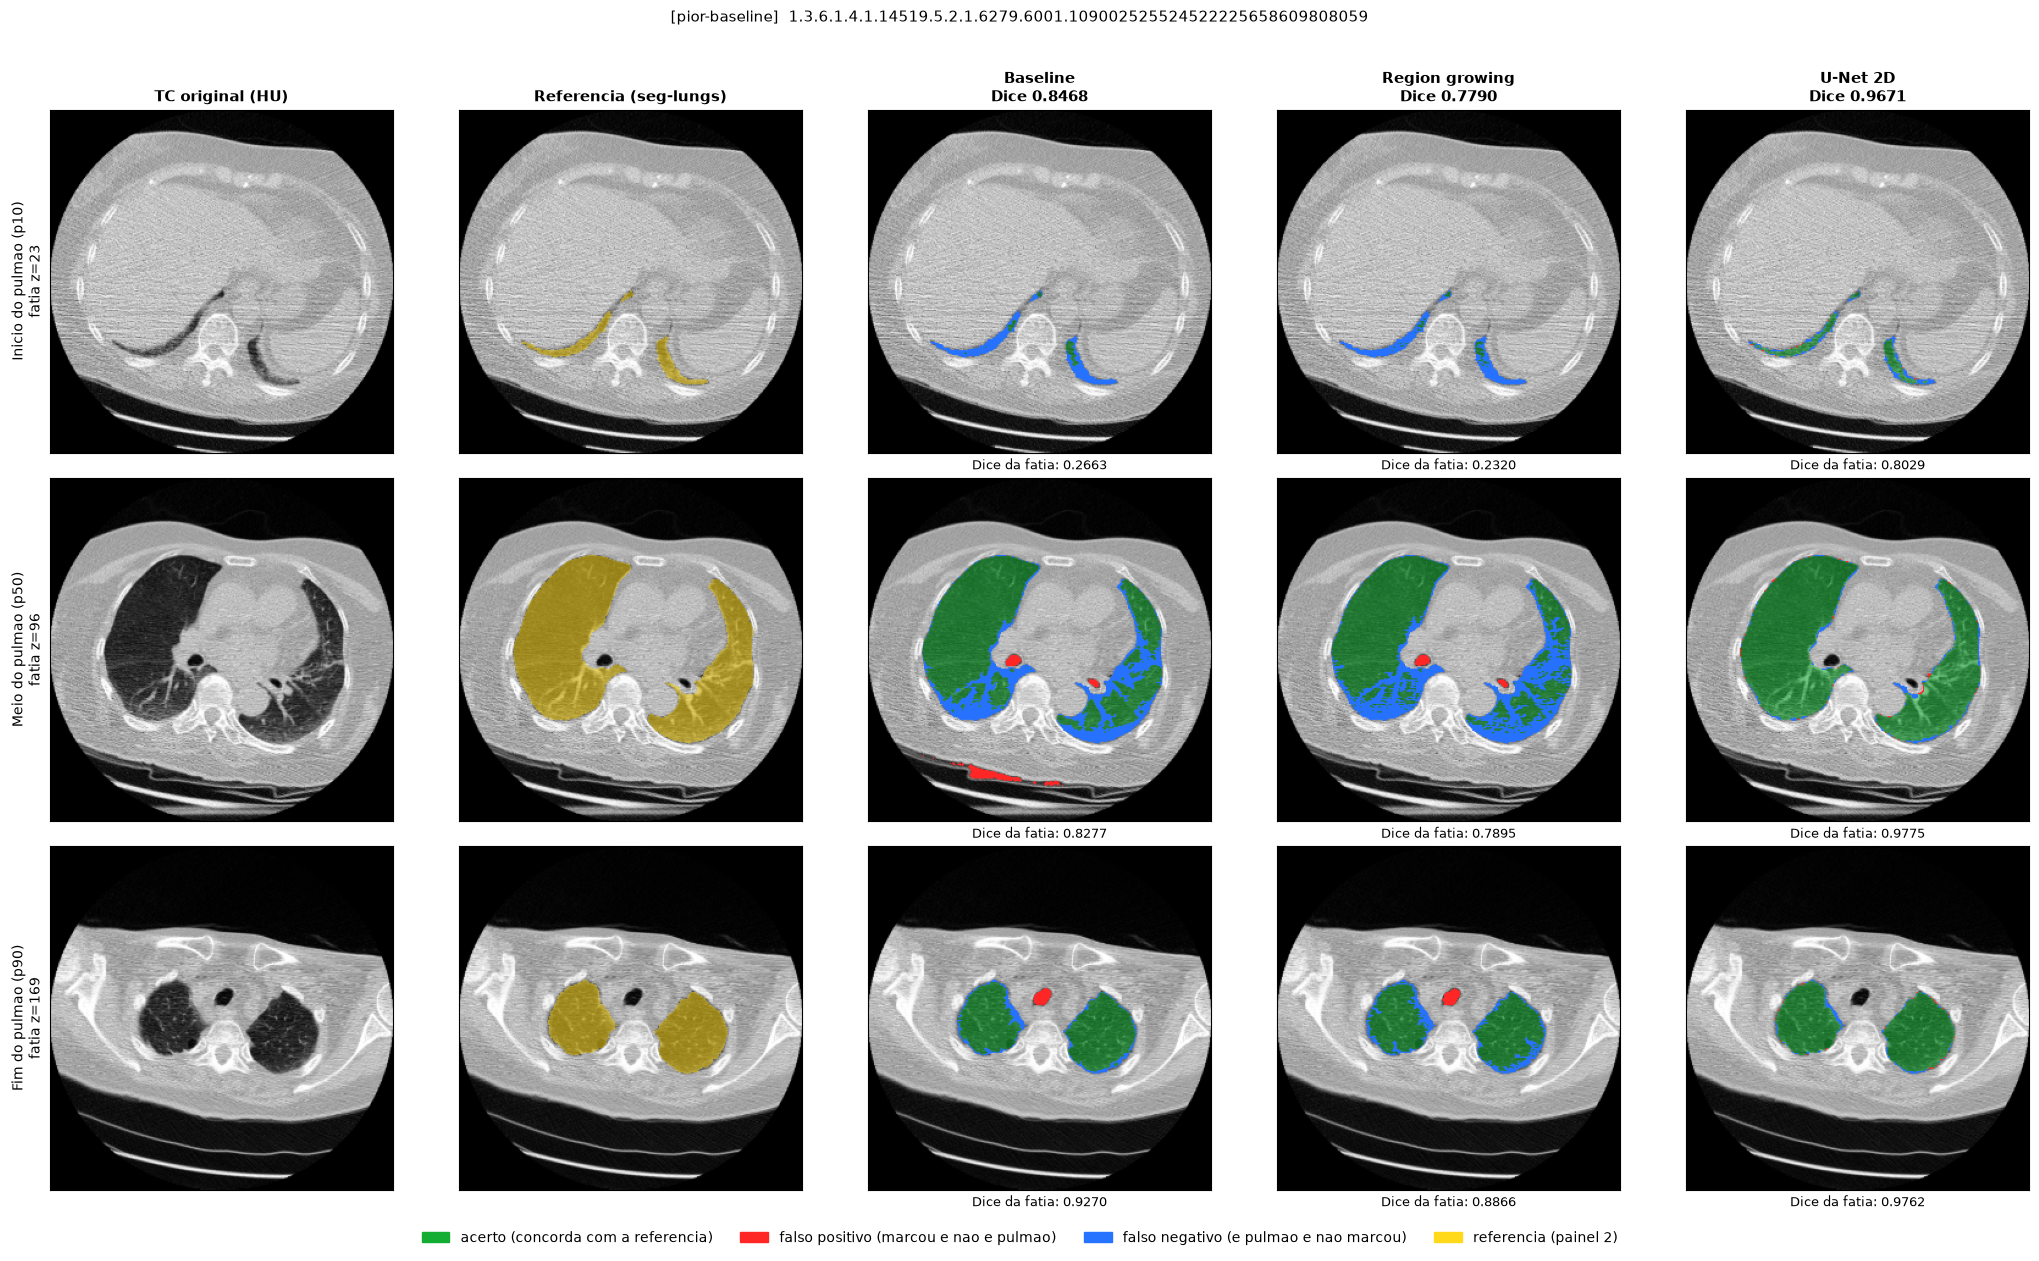

In [5]:
display(Image(filename=str(figuras['pior-baseline'])))

**Baseline 0,847 · Region growing 0,779 · U-Net 0,967**

Na fatia do meio, o pulmão esquerdo (à direita na imagem) aparece **bem mais denso e
acinzentado** que o direito, que está normalmente aerado e escuro; a mesma textura densa
cobre a porção posterior do pulmão direito. A referência marca todo esse território como
parênquima, mas ele está **acima de −600 HU** — então o baseline e o region growing o
descartam em bloco, e a sobreposição dos dois fica quase toda azul justamente ali
(Dice da fatia 0,83 e 0,79). A U-Net recupera quase tudo (0,98) porque aprendeu **onde o
pulmão fica e que forma ele tem**, não só quão escuro ele é — ela não depende de o voxel
passar num corte de intensidade.

### 3.2. Fatia grossa (2,5 mm) — `…021509831276`

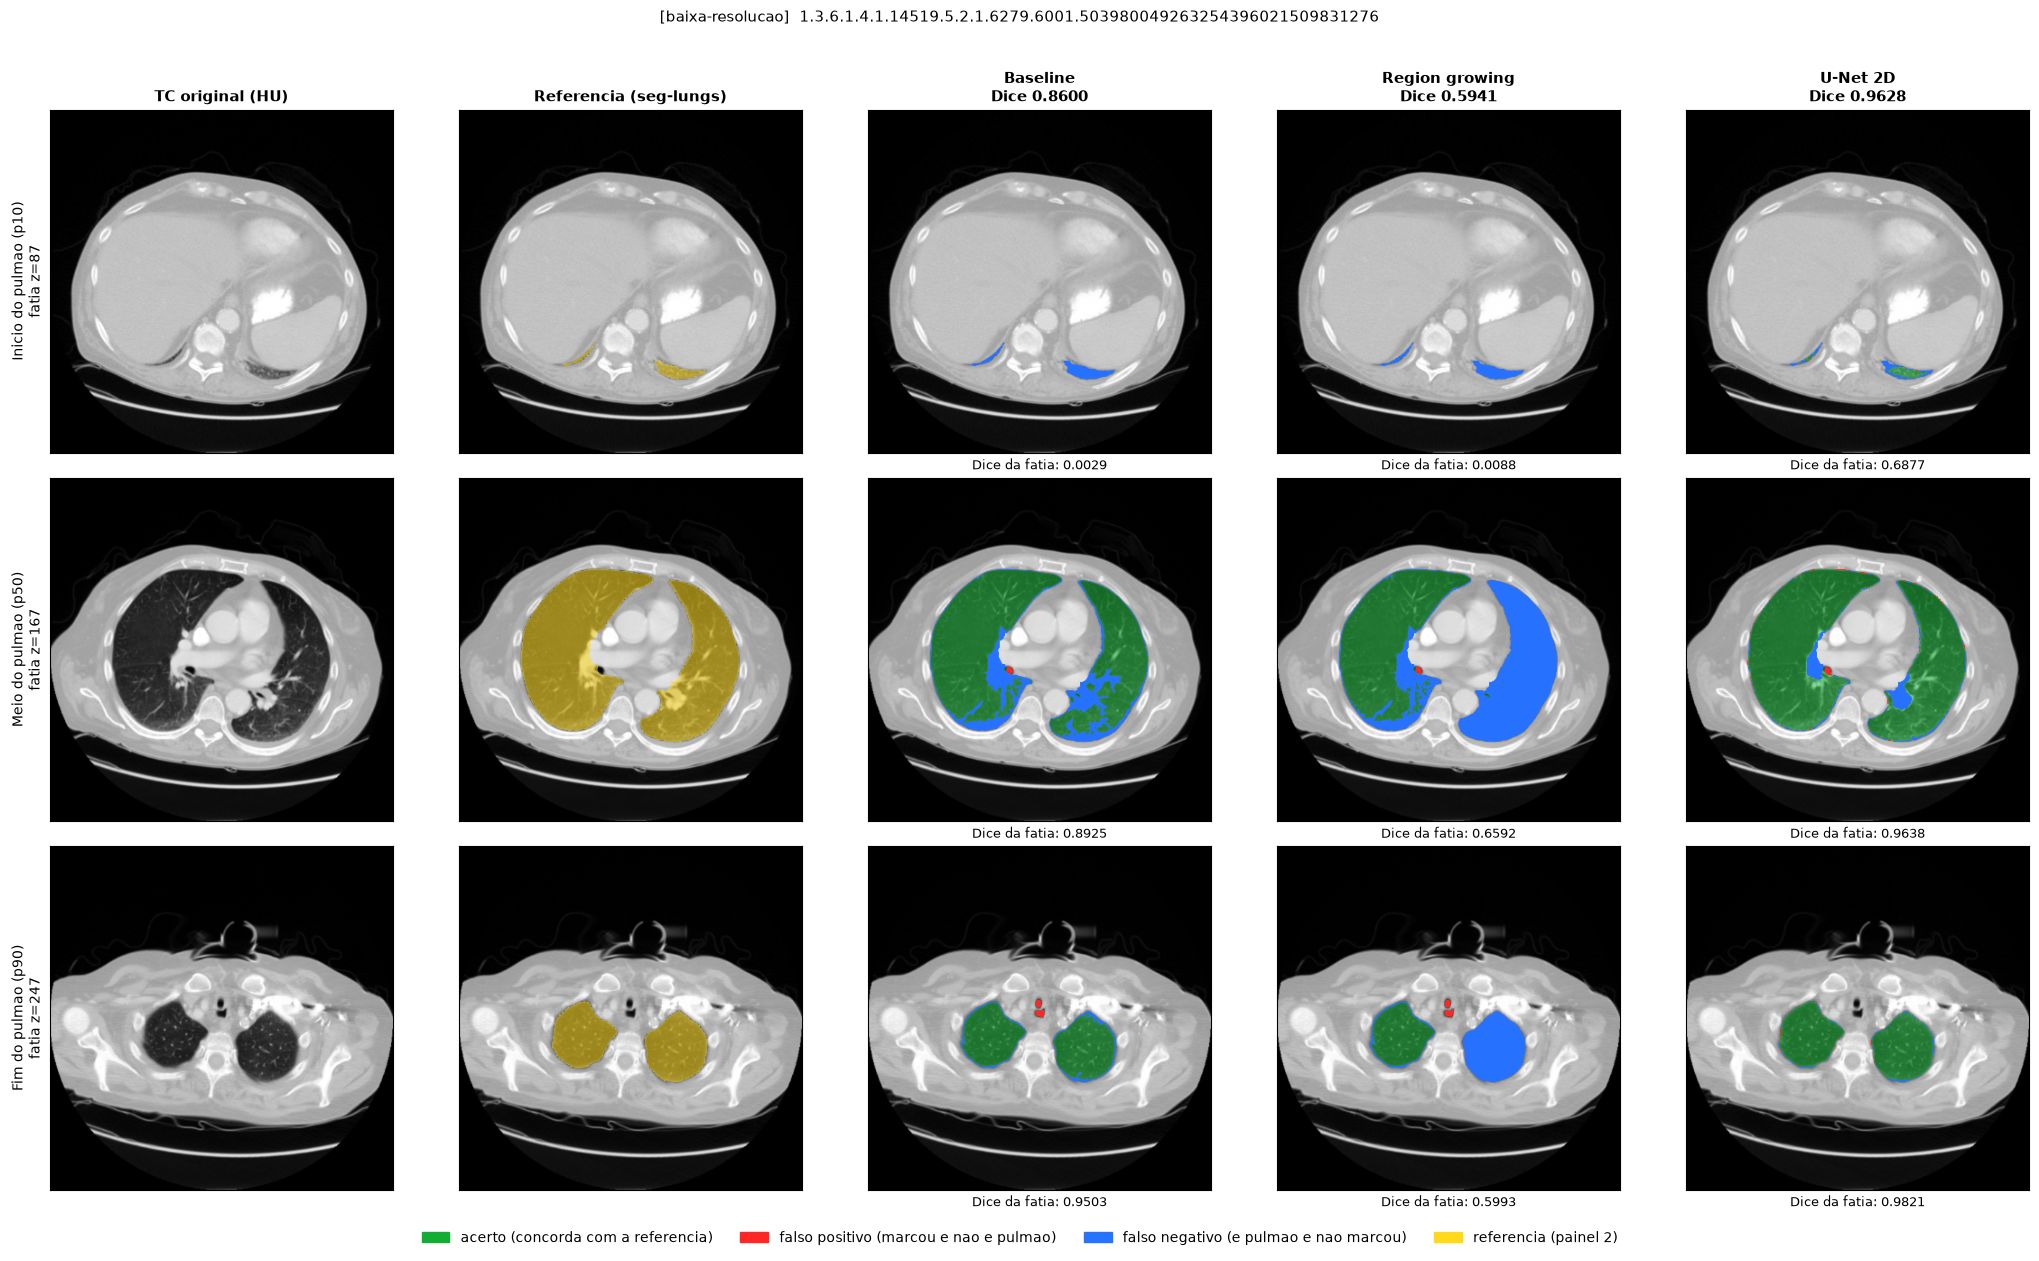

In [6]:
display(Image(filename=str(figuras['baixa-resolucao'])))

**Baseline 0,860 · Region growing 0,594 · U-Net 0,963**

Com fatias de 2,5 mm, cada voxel mistura 2,5 mm de anatomia, e a borda pulmão/tecido vira
uma faixa de transição larga em vez de uma fronteira nítida — o efeito de volume parcial.
No meio do pulmão, o baseline fica **rendilhado**, cheio de buracos, onde essa mistura
empurra o valor acima do limiar. O region growing vai muito pior: nas fatias do meio e do
topo ele **perde o pulmão esquerdo inteiro** (todo azul), porque o crescimento não
atravessa a faixa de transição e a região simplesmente não propaga. A U-Net atravessa
porque reconhece o contorno pela forma, mesmo com a borda borrada.

### 3.3. Caso difícil intermediário — `…954024478441`

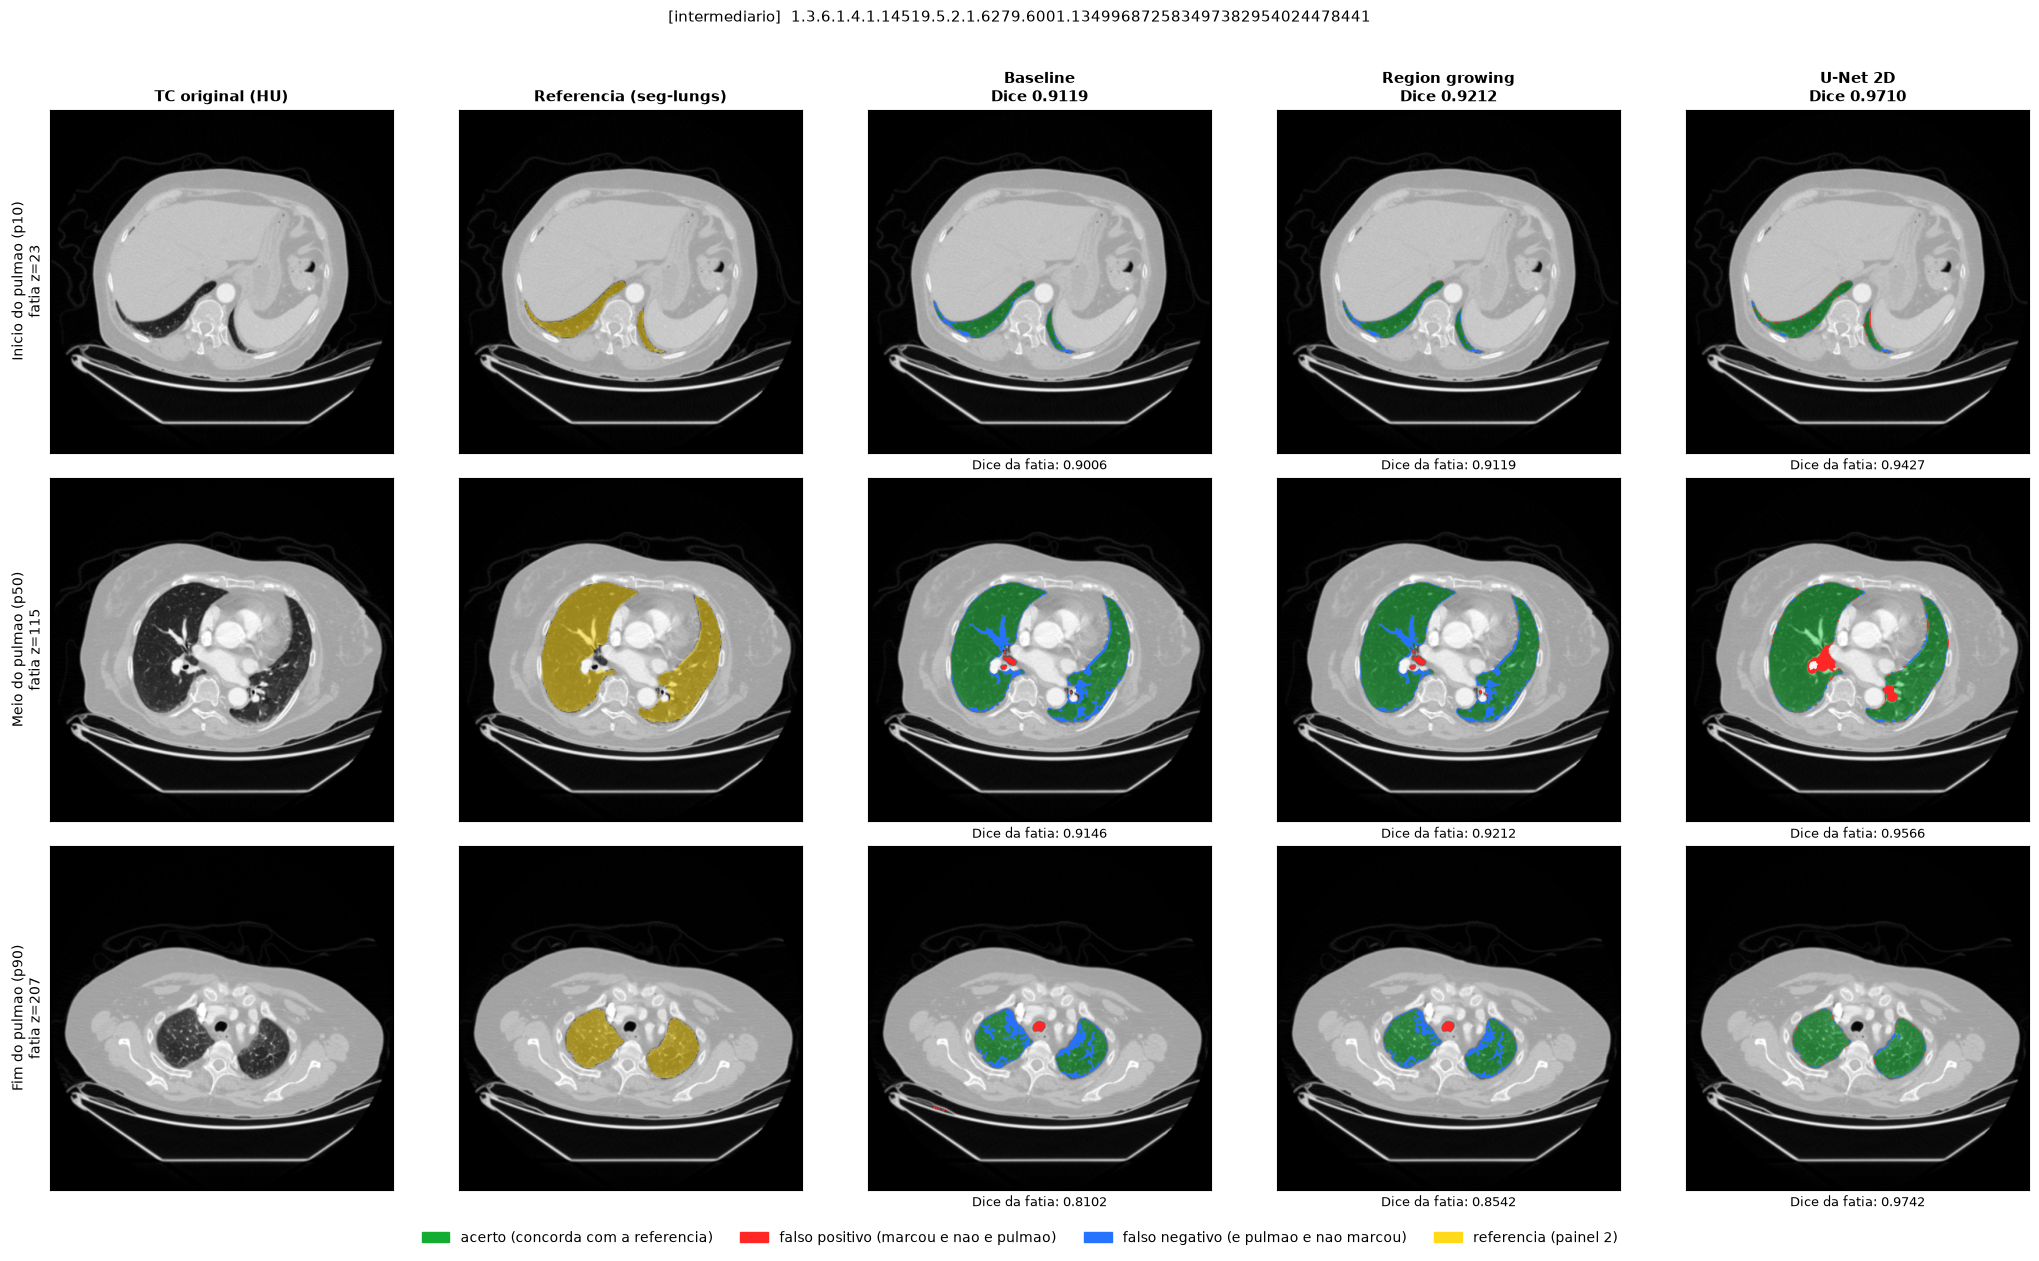

In [7]:
display(Image(filename=str(figuras['intermediario'])))

**Baseline 0,912 · Region growing 0,921 · U-Net 0,971**

Aqui os três sofrem juntos, o que o torna útil: é o caso em que a dificuldade é **do
exame**, não de um método. O pulmão esquerdo aparece mais denso e com menos contraste em
relação ao mediastino, e nas fatias do meio e do topo tanto o baseline quanto o region
growing deixam grandes áreas azuis nessa região. A U-Net recupera a maior parte, mas é
também onde ela mostra o seu próprio defeito: uma mancha vermelha junto ao hilo, incluindo
estrutura mediastinal que não é parênquima.

### 3.4. Colapso do region growing — `…079549658100`

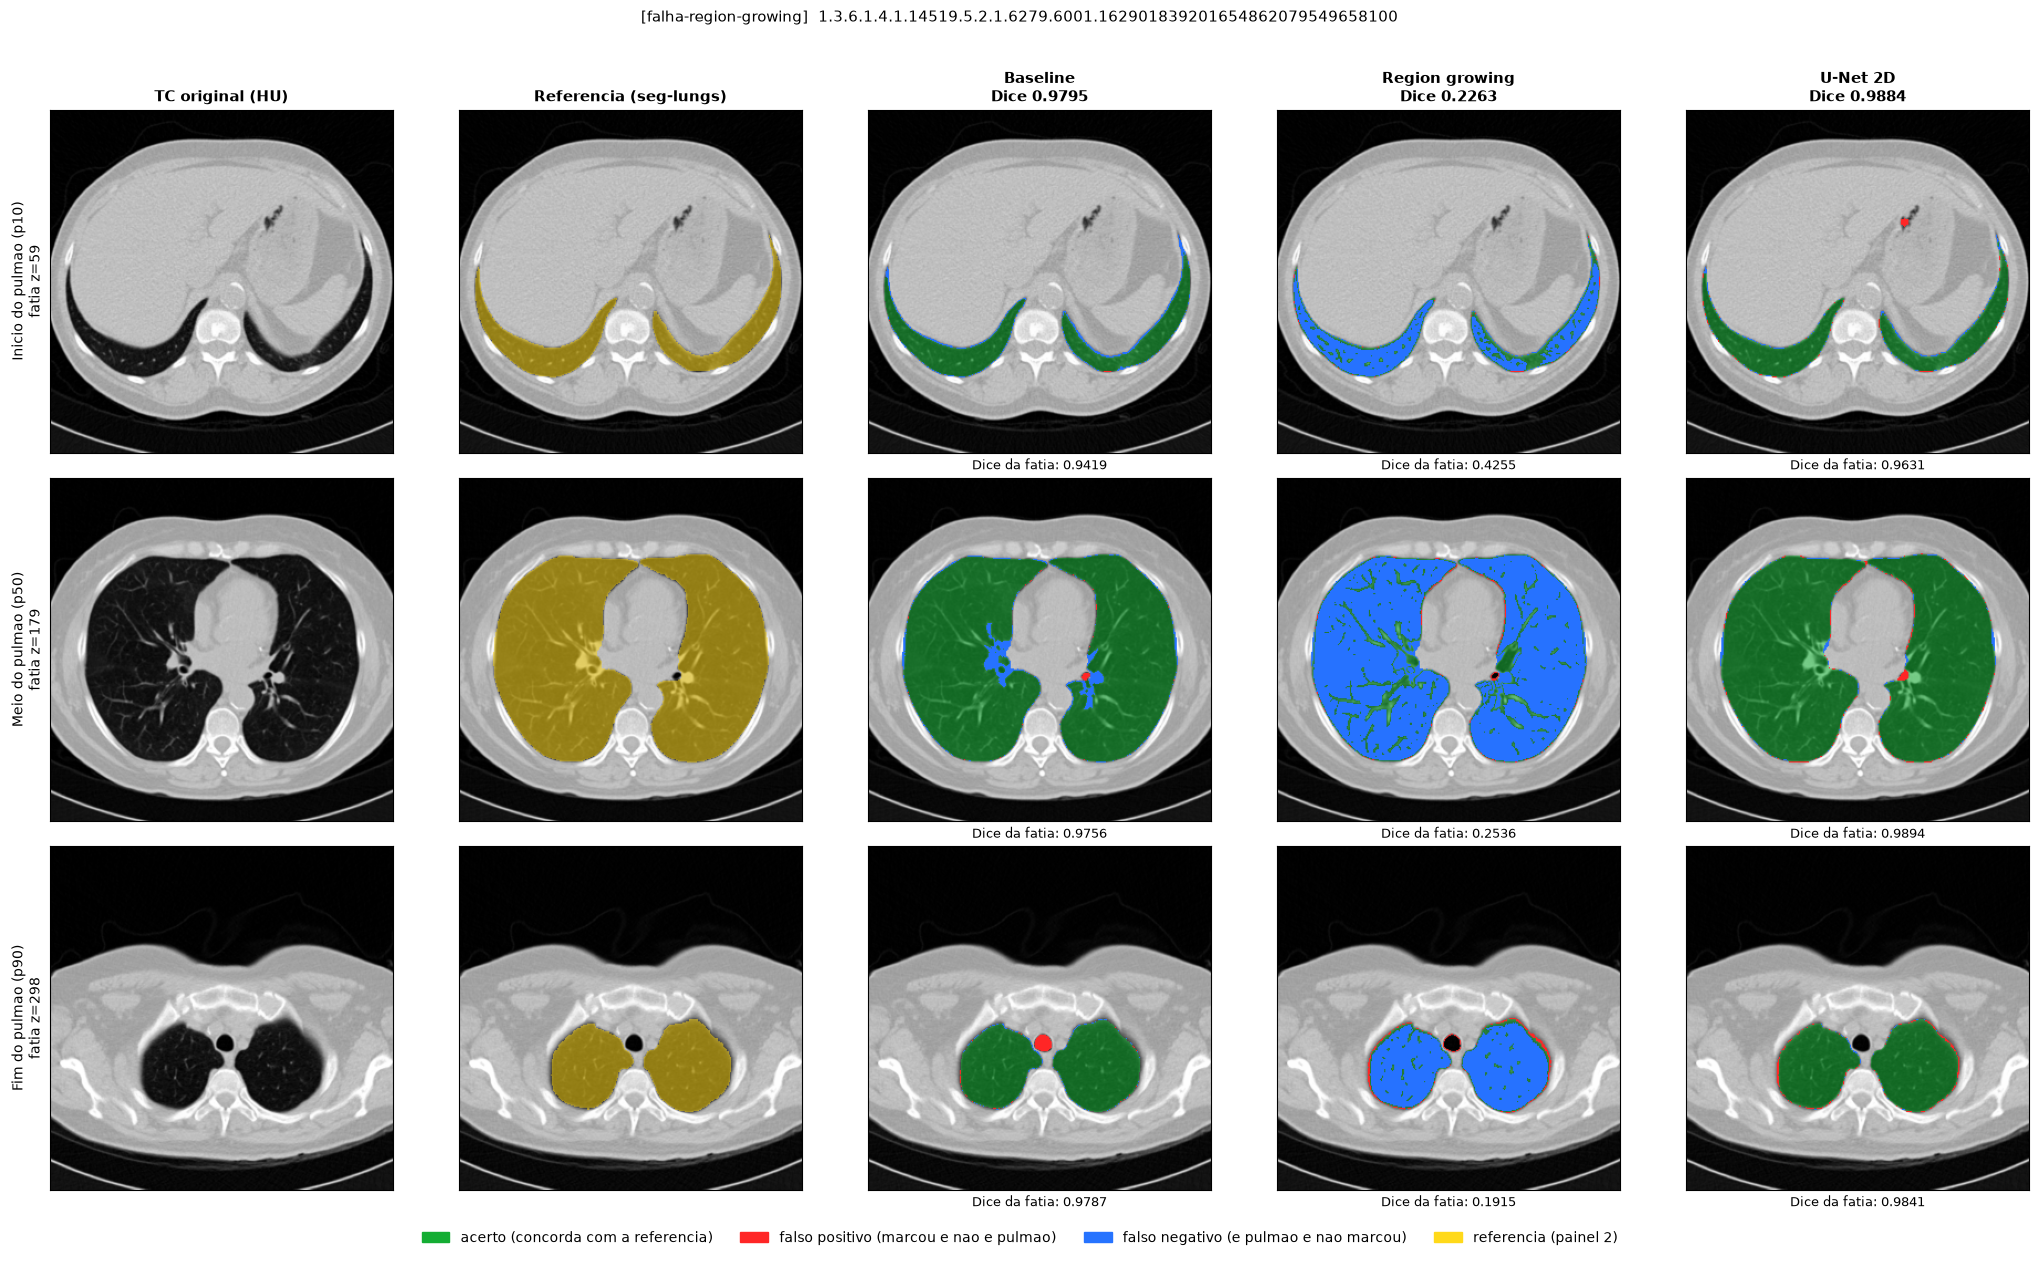

In [8]:
display(Image(filename=str(figuras['falha-region-growing'])))

**Baseline 0,980 · Region growing 0,226 · U-Net 0,988**

Este exame **não é difícil**: a TC está limpa, bem aerada, e baseline e U-Net passam de
0,98. Ainda assim o region growing marca 0,226. A imagem mostra o motivo: a predição dele
não cobre o ar do pulmão — ela desenha uma **árvore ramificada** que acompanha os vasos e a
borda pleural, fragmentada em **2.655 componentes** (contra 5 do baseline e 2 da U-Net). É
falha de semente, não do exame — ver a seção 4, onde isso é verificado numericamente.

### 3.5. O único caso em que a U-Net perde — `…696274044574`

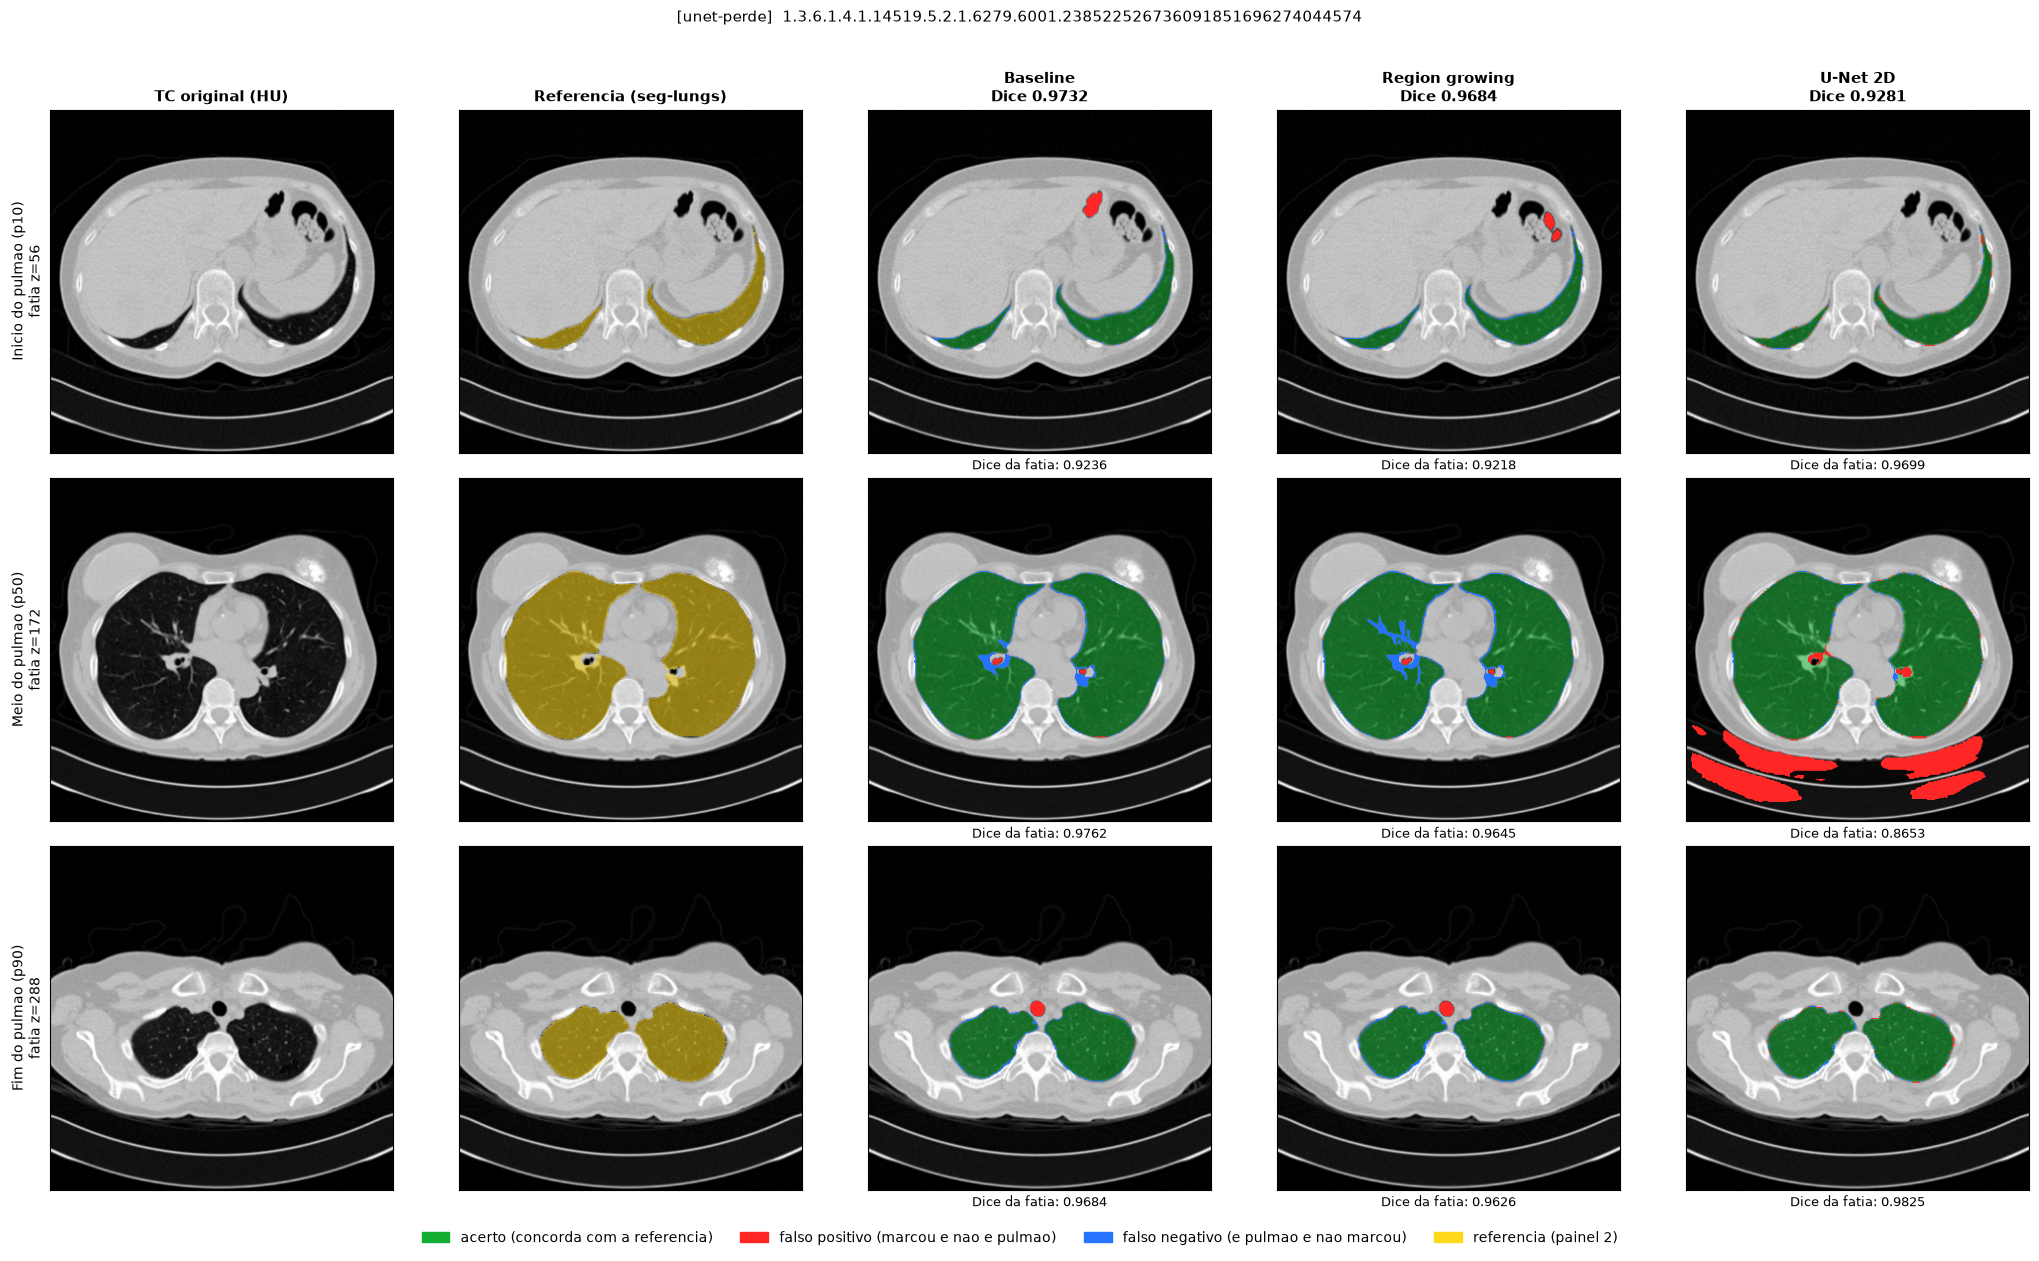

In [9]:
display(Image(filename=str(figuras['unet-perde'])))

**Baseline 0,973 · Region growing 0,968 · U-Net 0,928**

Na fatia do meio aparecem **grandes manchas vermelhas na borda inferior da imagem, fora do
corpo do paciente**: a U-Net marcou como pulmão os bolsões de ar do colchão e da mesa do
tomógrafo. São **672,5 mL de falso positivo**, contra 64,2 mL do baseline — dez vezes mais.
O baseline e o region growing não caem nessa porque têm uma regra explícita que apaga tudo
o que toca a borda da imagem (`remove_background_per_slice`); a U-Net não tem regra nenhuma,
só o que aprendeu, e ali o colchão tem a mesma aparência local de pulmão: escuro, cercado
de material mais claro. Curiosamente, **na fatia de baixo a relação se inverte**: o baseline
e o region growing marcam ar gástrico em vermelho e a U-Net não.

### 3.6. CONTROLE — exame em que os três vão bem — `…741695800950`

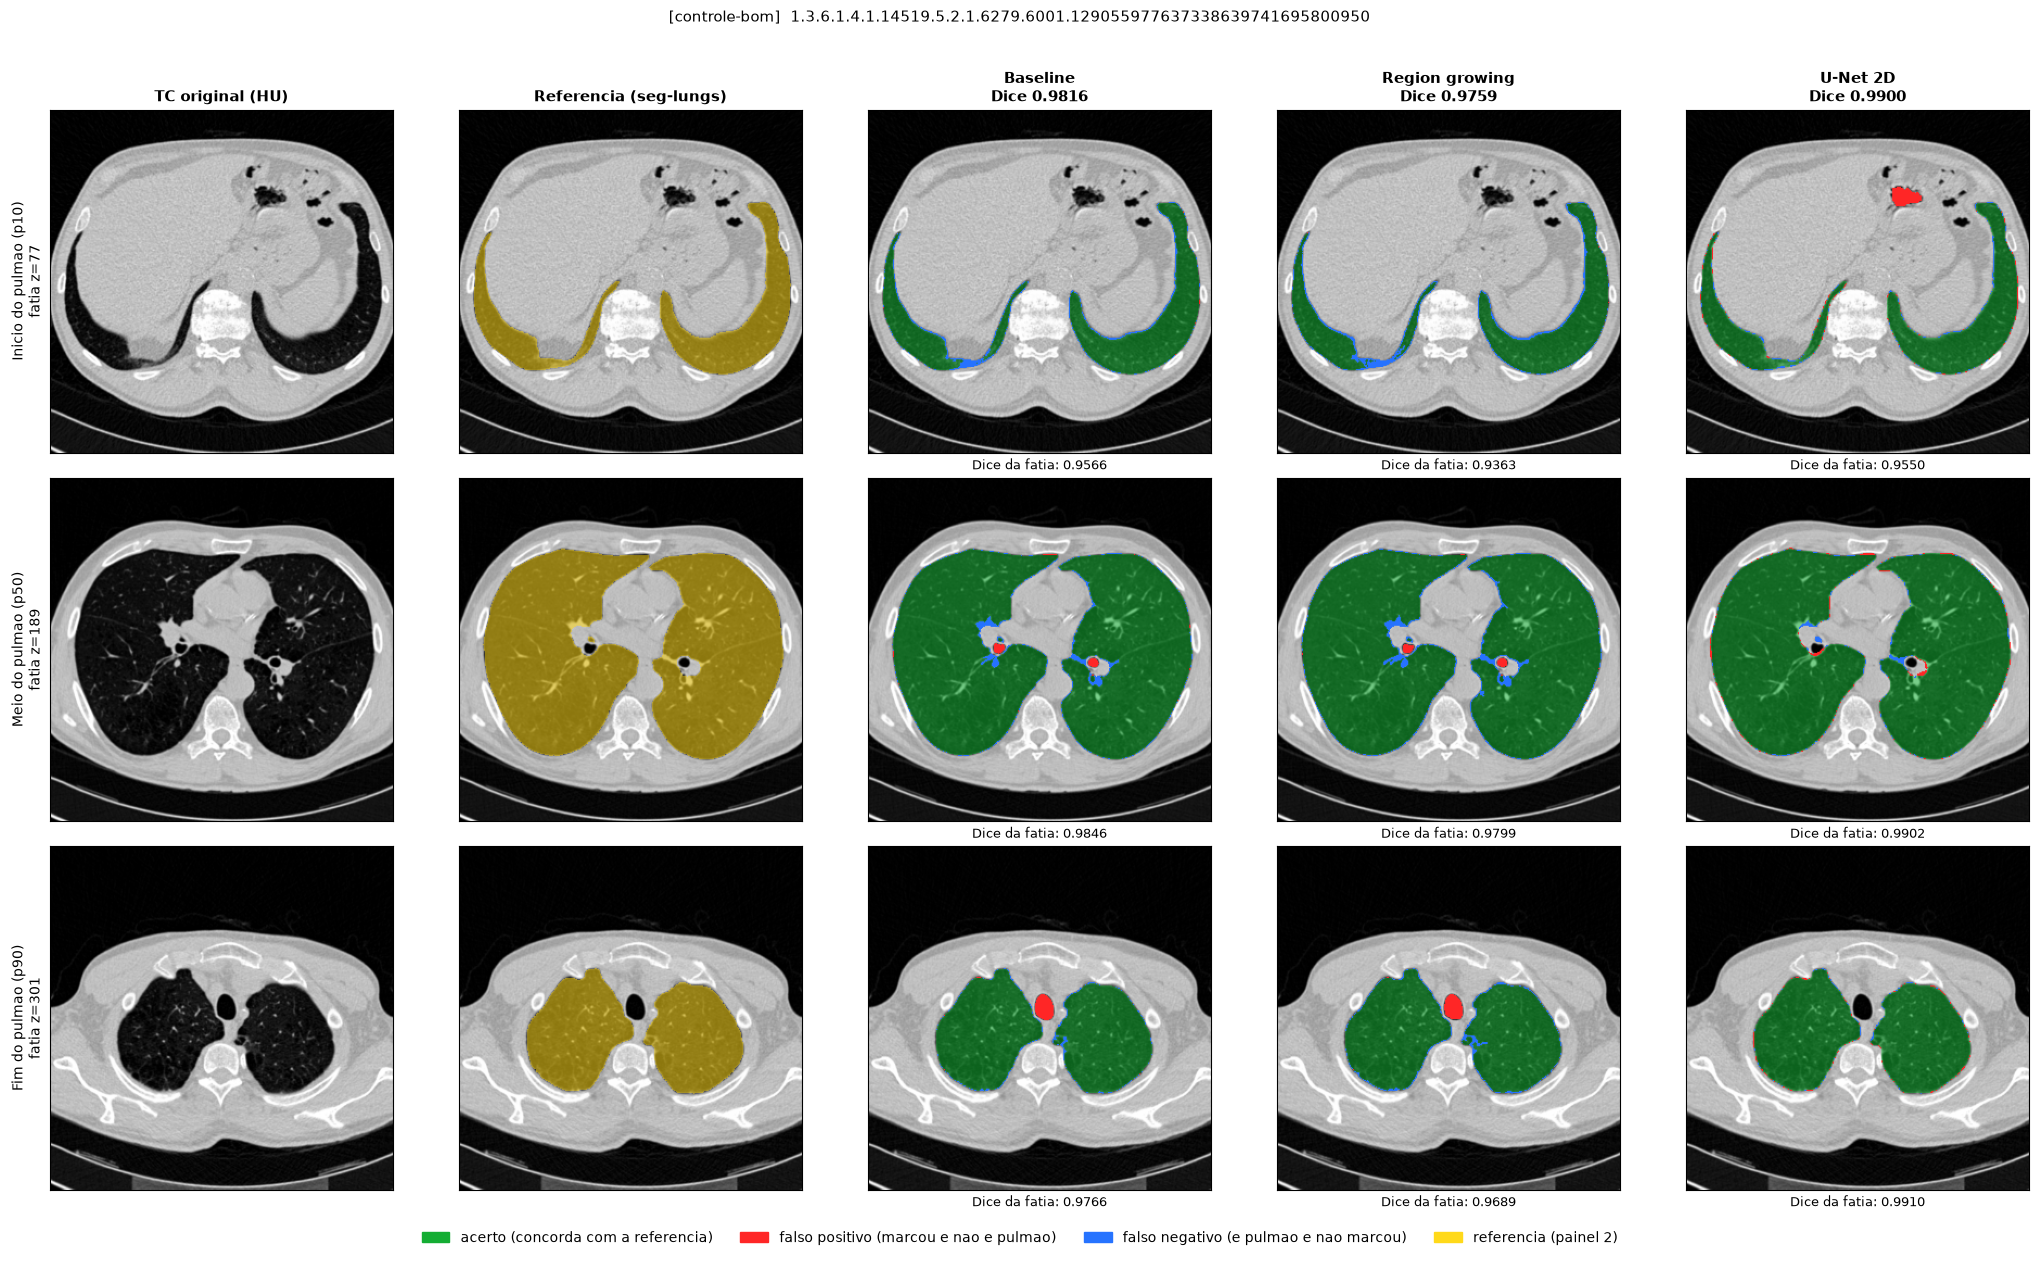

In [10]:
display(Image(filename=str(figuras['controle-bom'])))

**Baseline 0,982 · Region growing 0,976 · U-Net 0,990**

Serve de régua: TC bem aerada, fatias finas (0,7 mm), contraste nítido entre pulmão e
tecido. Os três painéis ficam quase inteiramente verdes, e as diferenças caem para
detalhes. Dois deles valem registro, porque são **sistemáticos e invisíveis no Dice**: na
fatia de cima, baseline e region growing marcam a **traqueia** em vermelho (a referência a
exclui de propósito — traqueia não é parênquima) e a **U-Net não marca**; e na fatia de
baixo, a U-Net marca uma bolha de ar abdominal que os outros dois ignoram. Quando o exame é
fácil, o que sobra é o viés de cada método.

## 4. Por que o region growing colapsa: verificando a semente

A hipótese que a imagem sugere (seção 3.4) é testável. O region growing escolhe a semente
automaticamente e cresce incluindo vizinhos dentro de uma banda de ±200 HU **em torno do
valor da semente**. Se a semente cair num voxel de borda em vez de ar puro, a banda inteira
fica deslocada e o crescimento não atravessa o parênquima normal.

Parênquima pulmonar aerado fica tipicamente em torno de **−850 HU**. Basta ver onde a banda
cai em cada caso.

In [11]:
import SimpleITK as sitk
from luna16.io import load_ct
from luna16.preprocessing import clean_hu, denoise, resample_isotropic
from luna16.lung_air import label_largest_components
from luna16.region_growing import _find_seed_points, SEED_THRESHOLD_HU, FLOOD_TOLERANCE_HU

HU_PARENQUIMA = -850  # valor tipico de pulmao aerado

for uid, rotulo, _ in [c for c in CASOS if c[1] in ('falha-region-growing', 'controle-bom')]:
    ct = load_ct(uid, DATA_DIR)
    s = ct.to_sitk_image()
    img = sitk.GetImageFromArray(denoise(clean_hu(ct.array), 0.5).astype('int16'))
    img.CopyInformation(s)
    vol = sitk.GetArrayFromImage(resample_isotropic(img, (1., 1., 1.), is_mask=False))

    lab, keep = label_largest_components(vol < SEED_THRESHOLD_HU, 2)
    print(f'{rotulo}:')
    for sd in _find_seed_points(lab, keep):
        v = int(vol[sd])
        lo, hi = v - FLOOD_TOLERANCE_HU, v + FLOOD_TOLERANCE_HU
        cobre = lo <= HU_PARENQUIMA <= hi
        print(f'   semente HU={v:5d} -> banda [{lo}, {hi}]  '
              f'cobre parenquima aerado (-850 HU)? {"SIM" if cobre else "NAO"}')
    print()

falha-region-growing:


   semente HU= -602 -> banda [-802, -402]  cobre parenquima aerado (-850 HU)? NAO
   semente HU= -984 -> banda [-1184, -784]  cobre parenquima aerado (-850 HU)? SIM



controle-bom:


   semente HU= -912 -> banda [-1112, -712]  cobre parenquima aerado (-850 HU)? SIM
   semente HU= -967 -> banda [-1167, -767]  cobre parenquima aerado (-850 HU)? SIM



**Confirmado.** No exame que colapsa, uma das sementes cai em **−602 HU** — um voxel de
transição, não de ar — e a banda resultante **[−802, −402] não alcança os −850 HU do
parênquima aerado**. O crescimento fica preso na franja entre o pulmão e as estruturas
vizinhas, o que é exatamente a árvore ramificada da figura. No exame de controle as
sementes caem em −912 e −967 HU e as bandas cobrem o parênquima com folga.

Ou seja: o region growing não falha porque o exame é difícil — **ele falha porque a escolha
automática de semente é frágil**. É uma fragilidade de implementação, corrigível (exigir que
a semente esteja abaixo de, digamos, −750 HU, ou usar a mediana da região em vez do voxel
único), e isso é diferente das limitações do baseline, que são do método.

## 5. O ganho da U-Net se concentra nos casos difíceis?

Até aqui olhamos 6 exames. Esta seção testa a afirmação nos **26 do conjunto de teste**.

In [12]:
b = pd.read_csv(DATA_DIR / 'sprint4_baseline_test.csv')[['uid', 'dice']].rename(columns={'dice': 'baseline'})
r = pd.read_csv(DATA_DIR / 'sprint4_region_growing_test.csv')[['uid', 'dice']].rename(columns={'dice': 'region_growing'})
u = pd.read_csv(DATA_DIR / 'sprint_unet_test.csv')[['uid', 'dice']].rename(columns={'dice': 'unet'})

todos = b.merge(r, on='uid').merge(u, on='uid').sort_values('baseline')
todos['ganho'] = todos['unet'] - todos['baseline']

print(f"3 piores do baseline : ganho medio {todos.head(3)['ganho'].mean():+.4f}")
print(f"outros 23            : ganho medio {todos.tail(23)['ganho'].mean():+.4f}")
print(f"razao                : {todos.head(3)['ganho'].mean() / todos.tail(23)['ganho'].mean():.1f}x")
print()

todos['quartil'] = pd.qcut(todos['baseline'], 4, labels=['Q1 (mais dificil)', 'Q2', 'Q3', 'Q4 (mais facil)'])
print(todos.groupby('quartil', observed=True).agg(
    n=('ganho', 'size'), dice_baseline=('baseline', 'mean'),
    dice_unet=('unet', 'mean'), ganho_medio=('ganho', 'mean')).round(4).to_string())
print()
print(f"correlacao (Dice do baseline x ganho da U-Net): {todos['baseline'].corr(todos['ganho']):.3f}")
print(f"casos em que a U-Net perde: {(todos['ganho'] < 0).sum()} de 26 | pior perda: {todos['ganho'].min():+.4f}")

3 piores do baseline : ganho medio +0.0941
outros 23            : ganho medio +0.0133
razao                : 7.1x

                   n  dice_baseline  dice_unet  ganho_medio
quartil                                                    
Q1 (mais dificil)  7         0.9197     0.9733       0.0536
Q2                 6         0.9607     0.9794       0.0187
Q3                 6         0.9674     0.9829       0.0155
Q4 (mais facil)    7         0.9766     0.9778       0.0011

correlacao (Dice do baseline x ganho da U-Net): -0.920
casos em que a U-Net perde: 3 de 26 | pior perda: -0.0451


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(todos['baseline'], todos['ganho'], s=55, alpha=0.75, color='#2b6cb0', zorder=3)
ax1.axhline(0, color='#888', lw=1, ls='--')
ax1.set_xlabel('Dice do baseline (menor = caso mais dificil)')
ax1.set_ylabel('Ganho da U-Net (Dice U-Net - Dice baseline)')
ax1.set_title('Quanto pior o baseline, maior o ganho da U-Net')
ax1.grid(alpha=0.25, zorder=0)
for _, row in todos.nsmallest(3, 'baseline').iterrows():
    ax1.annotate(f"...{row['uid'][-6:]}", (row['baseline'], row['ganho']),
                 textcoords='offset points', xytext=(8, -2), fontsize=8)

q = todos.groupby('quartil', observed=True)['ganho'].mean()
cores = ['#c53030', '#dd6b20', '#38a169', '#2b6cb0']
ax2.bar(range(len(q)), q.values, color=cores, zorder=3)
ax2.set_xticks(range(len(q)))
ax2.set_xticklabels(q.index, fontsize=9)
ax2.axhline(0, color='#888', lw=1)
ax2.set_ylabel('Ganho medio da U-Net')
ax2.set_title('Ganho por quartil de dificuldade')
ax2.grid(alpha=0.25, axis='y', zorder=0)
for i, v in enumerate(q.values):
    ax2.text(i, v, f'{v:+.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'ganho_unet_por_dificuldade.png', dpi=110, bbox_inches='tight')
plt.show()

C:\Users\ruans\AppData\Local\Temp\ipykernel_25876\355514600.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Resposta

**A U-Net ganha mais nos casos difíceis do que na média — e por uma margem grande.** Nos 3
piores exames do baseline o ganho médio de Dice é **+0,0941**; nos outros 23 é **+0,0133**,
uma razão de **7,1×**. O efeito não vem de dois ou três pontos extremos: ele é monotônico ao
longo de todo o conjunto, caindo de **+0,0536** no quartil mais difícil para **+0,0011** no
mais fácil, com correlação de **−0,920** entre o Dice do baseline e o ganho. Em que tipo de
caso, concretamente: **naqueles em que o parênquima não está escuro o bastante para passar
num corte de intensidade** — regiões de maior densidade (caso 3.1), volume parcial por fatia
grossa de 2,5 mm (caso 3.2), e perda de contraste entre pulmão e mediastino (caso 3.3). Em
todos eles o erro dos métodos clássicos é o mesmo e é **falso negativo**: eles não erram o
que marcam, eles deixam de marcar; a U-Net recupera esse território porque decide por forma
e contexto, não por limiar. No extremo oposto, nos exames bem aerados os três métodos
empatam na prática (caso 3.6) e o que resta são vieses sistemáticos de cada um — e aí a
U-Net ainda leva vantagem num ponto que o Dice não mostra: ela aprendeu a **excluir a
traqueia** (média de 15,7% incluída, contra 84,6% do baseline e 71,1% do region growing).
A contrapartida é real e está no caso 3.5: sem a regra explícita de descartar o que toca a
borda da imagem, a U-Net pode marcar **ar da mesa do tomógrafo** (672,5 mL num único exame)
— um erro que nenhum dos métodos clássicos comete. **A conclusão prática para o artigo:** a
média esconde o argumento. Comparar os métodos pelo Dice médio (0,956 contra 0,978) sugere
um ganho modesto de dois pontos; olhar a distribuição mostra que a U-Net praticamente
elimina a cauda ruim — o Dice mínimo sobe de 0,847 para 0,928 e os exames abaixo de 0,85
caem de 1 para 0. É exatamente o padrão que o professor levantou na orientação 5, e ele se
confirma.

## 7. Para os outros cards

Os exames desta lista são bons candidatos a caso de falha na demonstração do front:

| Exame | O que demonstra |
|---|---|
| `…658609808059` | região densa: os clássicos perdem, a U-Net recupera — o argumento principal |
| `…079549658100` | colapso do region growing num exame fácil (0,226 contra 0,98 dos outros) |
| `…696274044574` | contraexemplo honesto: a U-Net erra, e erra feio, no ar da mesa |
| `…741695800950` | controle: os três acertam, serve de régua |

O caso `…696274044574` merece entrar na demonstração justamente por ser o contraexemplo: um
trabalho que só mostra onde o método proposto ganha é menos convincente que um que mostra
também onde ele perde, e por quê.

Complementa o card "Olhar visualmente ≥10 exames aleatórios"
(`entrega/inspecao_visual/`), que cobriu 12 exames sorteados mas só o baseline.